<a href="https://colab.research.google.com/github/Aaricis/Hung-yi-Lee-ML2022/blob/main/HW13/network_pruning_example_for_report_Q3_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch import nn
import torch.nn.utils.prune as prune
import torch.nn.functional as F

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        # 1 input image channel, 6 output channels, 3x3 square conv kernel
        self.conv1 = nn.Conv2d(1, 6, 3)
        self.conv2 = nn.Conv2d(6, 16, 3)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)  # 5x5 image dimension
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), (2, 2))
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = x.view(-1, int(x.nelement() / x.shape[0]))
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = LeNet().to(device=device)

Let's say now you want to prune all the parameters named with `weight` in all the `nn.Conv2d` layers in the `model`, with pruning ratio **0.2**. Then please refer to the code below to achieve this.

In [ ]:
ratio = 0.2 # specify the pruning ratio
for name, module in model.named_modules():
    if isinstance(module, torch.nn.Conv2d): # if the nn.module is torch.nn.Conv2d
        prune.l1_unstructured(module, name='weight', amount=ratio) # use 'prune' method provided by 'torch.nn.utils.prune' to prune the weight parameters in the nn.Conv2d layers
# Next, you just have to generize the above code to different ratio and test the accuracy on the validation set of food11-hw13.

In [2]:
# fetch and download the dataset from github (about 1.12G)
# !wget https://github.com/virginiakm1988/ML2022-Spring/raw/main/HW13/food11-hw13.tar.gz
## backup links:

!wget https://github.com/andybi7676/ml2022spring-hw13/raw/main/food11-hw13.tar.gz -O food11-hw13.tar.gz
# !gdown '1ijKoNmpike_yjUw8SWRVVWVoMOXXqycj' --output food11-hw13.tar.gz

--2025-06-12 14:38:43--  https://github.com/andybi7676/ml2022spring-hw13/raw/main/food11-hw13.tar.gz
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://media.githubusercontent.com/media/andybi7676/ml2022spring-hw13/main/food11-hw13.tar.gz [following]
--2025-06-12 14:38:44--  https://media.githubusercontent.com/media/andybi7676/ml2022spring-hw13/main/food11-hw13.tar.gz
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1203320552 (1.1G) [application/octet-stream]
Saving to: ‘food11-hw13.tar.gz’

food11-hw13.tar.gz  100%[===================>]   1.12G   205MB/s    in 5.1s    

2025-06-12 14:40:57 (226 MB/s) - ‘food11-

In [3]:
# extract the data
!tar -xzf ./food11-hw13.tar.gz # Could take some time
# !tar -xzvf ./food11-hw13.tar.gz # use this command if you want to checkout the whole process.

In [5]:
import os
import copy
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.v2 as transforms
from PIL import Image
from tqdm.auto import tqdm
import torch.nn as nn
import numpy as np
import time
import random

In [6]:
for dirname, _, filenames in os.walk('./food11-hw13'):
    if len(filenames) > 0:
        print(f"{dirname}: {len(filenames)} files.") # Show the file amounts in each split.

./food11-hw13: 1 files.
./food11-hw13/validation: 3430 files.
./food11-hw13/training: 9866 files.
./food11-hw13/evaluation: 3347 files.


In [7]:
cfg = {
    'dataset_root': './food11-hw13',
    'save_dir': './outputs',
    'exp_name': 'strong_baseline', #"simple_baseline",
    'batch_size': 64,
    'lr': 3e-4,
    'seed': 20220013,
    'loss_fn_type': 'KD', #'CE', # simple baseline: CE, medium baseline: KD. See the Knowledge_Distillation part for more information.
    'weight_decay': 1e-5,
    'grad_norm_max': 10, # 最大允许的梯度范数（阈值）
    'n_epochs': 300, #50, #10, # train more steps to pass the medium baseline.
    'patience': 50, #300,
}

In [8]:
myseed = cfg['seed']  # set a random seed for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
np.random.seed(myseed)
torch.manual_seed(myseed)
random.seed(myseed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(myseed)

In [9]:
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# define training/testing transforms
test_tfm = transforms.Compose([
    # It is not encouraged to modify this part if you are using the provided teacher model. This transform is stardard and good enough for testing.
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    normalize,
])

/usr/local/lib/python3.11/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [10]:
class FoodDataset(Dataset):
    def __init__(self, path, tfm=test_tfm, files = None):
        super().__init__()
        self.path = path
        self.files = sorted([os.path.join(path,x) for x in os.listdir(path) if x.endswith(".jpg")])
        if files != None:
            self.files = files
        print(f"One {path} sample",self.files[0])
        self.transform = tfm

    def __len__(self):
        return len(self.files)

    def __getitem__(self,idx):
        fname = self.files[idx]
        im = Image.open(fname)
        im = self.transform(im)
        try:
            label = int(fname.split("/")[-1].split("_")[0])
        except:
            label = -1 # test has no label
        return im,label

In [11]:
valid_set = FoodDataset(os.path.join(cfg['dataset_root'], "validation"), tfm=test_tfm)
valid_loader = DataLoader(valid_set, batch_size=cfg['batch_size'], shuffle=False, num_workers=0, pin_memory=True)

One ./food11-hw13/validation sample ./food11-hw13/validation/0_0.jpg


In [12]:
# Load provided teacher model (model architecture: resnet18, num_classes=11, test-acc ~= 89.9%)
teacher_model = torch.hub.load('pytorch/vision:v0.10.0', 'resnet18', pretrained=False, num_classes=11)
# load state dict
teacher_ckpt_path = os.path.join(cfg['dataset_root'], "resnet18_teacher.ckpt")
teacher_model.load_state_dict(torch.load(teacher_ckpt_path, map_location='cpu'))
# Now you already know the teacher model's architecture. You can take advantage of it if you want to pass the strong or boss baseline.
# Source code of resnet in pytorch: (https://github.com/pytorch/vision/blob/main/torchvision/models/resnet.py)
# You can also see the summary of teacher model. There are 11,182,155 parameters totally in the teacher model
# summary(teacher_model, (3, 224, 224), device='cpu')

Downloading: "https://github.com/pytorch/vision/zipball/v0.10.0" to /root/.cache/torch/hub/v0.10.0.zip
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


<All keys matched successfully>

In [13]:
# "cuda" only when GPUs are available.
device = "cuda" if torch.cuda.is_available() else "cpu"
teacher_model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [14]:
loss_fn = nn.CrossEntropyLoss()

In [15]:
# ---------- Validation ----------
# Make sure the model is in eval mode so that some modules like dropout are disabled and work normally.
teacher_model.eval()
# These are used to record information in validation.
valid_loss = []
valid_accs = []
valid_lens = []

# Iterate the validation set by batches.
for batch in tqdm(valid_loader):

    # A batch consists of image data and corresponding labels.
    imgs, labels = batch
    imgs = imgs.to(device)
    labels = labels.to(device)

    # We don't need gradient in validation.
    # Using torch.no_grad() accelerates the forward process.
    with torch.no_grad():
        logits = teacher_model(imgs) # MEDIUM BASELINE

    # We can still compute the loss (but not the gradient).
    loss = loss_fn(logits, labels) # SIMPLE BASELINE

    # Compute the accuracy for current batch.
    acc = (logits.argmax(dim=-1) == labels).float().sum()

    # Record the loss and accuracy.
    batch_len = len(imgs)
    valid_loss.append(loss.item() * batch_len)
    valid_accs.append(acc)
    valid_lens.append(batch_len)
    #break

# The average loss and accuracy for entire validation set is the average of the recorded values.
valid_loss = sum(valid_loss) / sum(valid_lens)
valid_acc = sum(valid_accs) / sum(valid_lens)

print(f"Valid loss = {valid_loss:.5f}, acc = {valid_acc:.5f}")

  0%|          | 0/54 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [16]:
# 执行L1非结构化剪枝
def prune_model(model, ratio):
  for name, module in model.named_modules():
    if isinstance(module, torch.nn.Conv2d): # if the nn.module is torch.nn.Conv2d
        prune.l1_unstructured(module, name='weight', amount=ratio)
        prune.remove(module, 'weight')  # 永久化剪枝
  return model

# 验证剪枝效果
def calculate_sparsity(model):
  """计算模型的全局稀疏度"""
  total_zeros = 0
  total_params = 0
  for module in model.modules():
      if isinstance(module, torch.nn.Conv2d):
          total_zeros += torch.sum(module.weight == 0)
          total_params += module.weight.numel()
  return 100 * (total_zeros / total_params).item()


# 评估剪枝后模型
def evaluate(model):
  # ---------- Validation ----------
  # Make sure the model is in eval mode so that some modules like dropout are disabled and work normally.
  model.eval()
  # These are used to record information in validation.
  valid_loss = []
  valid_accs = []
  valid_lens = []

  # Iterate the validation set by batches.
  for batch in tqdm(valid_loader):

      # A batch consists of image data and corresponding labels.
      imgs, labels = batch
      imgs = imgs.to(device)
      labels = labels.to(device)

      # We don't need gradient in validation.
      # Using torch.no_grad() accelerates the forward process.
      with torch.no_grad():
          logits = model(imgs) # MEDIUM BASELINE

      # We can still compute the loss (but not the gradient).
      loss = loss_fn(logits, labels) # SIMPLE BASELINE

      # Compute the accuracy for current batch.
      acc = (logits.argmax(dim=-1) == labels).float().sum()

      # Record the loss and accuracy.
      batch_len = len(imgs)
      valid_loss.append(loss.item() * batch_len)
      valid_accs.append(acc)
      valid_lens.append(batch_len)
      #break

  # The average loss and accuracy for entire validation set is the average of the recorded values.
  valid_loss = sum(valid_loss) / sum(valid_lens)
  valid_acc = sum(valid_accs) / sum(valid_lens)

  print(f"Valid loss = {valid_loss:.5f}, acc = {valid_acc:.5f}")

  return valid_acc

In [17]:
acc_list = []
ratio_list = np.arange(0, 1, 0.05)

for ratio in ratio_list:
  print(f"ratio = {ratio}")
  model_copy = copy.deepcopy(teacher_model)
  pruned_model = prune_model(model_copy, ratio)
  sparsity = calculate_sparsity(pruned_model)

  start_time = time.time()  # 记录开始时间
  acc = evaluate(pruned_model)
  end_time = time.time()  # 记录结束时间
  elapsed_time = end_time - start_time  # 计算耗时

  acc_list.append(acc.item())
  print(f"prune_{ratio:.0%}: Accuracy={acc}, Sparsity={sparsity:.2f}%, 代码运行耗时:{elapsed_time:.4f} 秒")

ratio = 0.0


  0%|          | 0/54 [00:00<?, ?it/s]

Valid loss = 0.59344, acc = 0.87143
prune_0%: Accuracy=0.8714285492897034, Sparsity=0.00%, 代码运行耗时:26.6466 秒
ratio = 0.05


  0%|          | 0/54 [00:00<?, ?it/s]

Valid loss = 0.59325, acc = 0.86997
prune_5%: Accuracy=0.8699707984924316, Sparsity=5.00%, 代码运行耗时:29.3764 秒
ratio = 0.1


...

Valid loss = 3.15740, acc = 0.10554
prune_85%: Accuracy=0.10553935170173645, Sparsity=85.00%, 代码运行耗时:28.1857 秒
ratio = 0.9


  0%|          | 0/54 [00:00<?, ?it/s]

Valid loss = 3.29426, acc = 0.10233
prune_90%: Accuracy=0.10233235359191895, Sparsity=90.00%, 代码运行耗时:26.3030 秒
ratio = 0.9500000000000001


  0%|          | 0/54 [00:00<?, ?it/s]

Valid loss = 3.88287, acc = 0.10117
prune_95%: Accuracy=0.10116617381572723, Sparsity=95.00%, 代码运行耗时:26.5171 秒


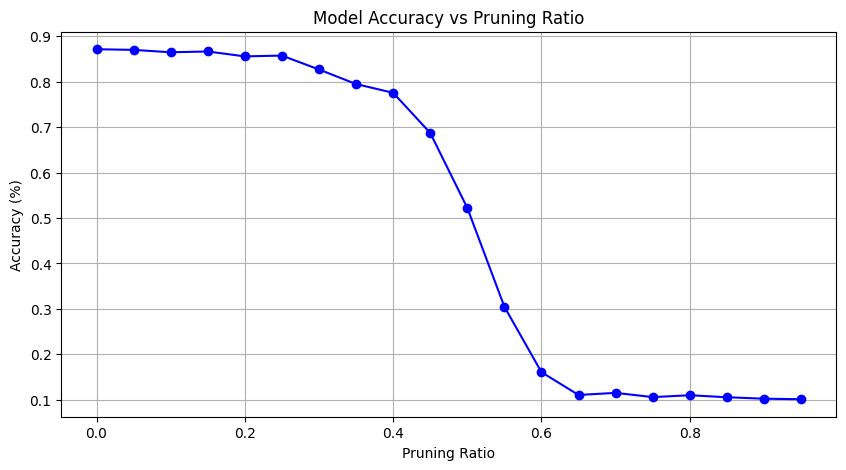

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(ratio_list, acc_list, 'bo-')
plt.xlabel('Pruning Ratio')
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy vs Pruning Ratio')
plt.grid(True)
plt.show()